This notebook numerically solves the geodesic equations of General Relativity using the fourth-order Runge–Kutta (RK4) method. It simulates the motion of particles and photons around a Schwarzschild black hole and visualizes their trajectories through orbit plots and animations, demonstrating the effects of curved spacetime on their motion.

In [19]:
import numpy as np #for math
import matplotlib.pyplot as plt #plotting
from matplotlib.animation import FuncAnimation #for animation

In [20]:
G = c = 1
M = 1

#Defining Constant
For simplicity using geometric units

M = black hole mass

This is common in General Relativity.

#Schwarzschild Metric
The motion of particles around a non-rotating black hole is described by the Schwarzschild metric, which represents the geometry of spacetime outside a spherical mass.


$$
ds^2 = -\left(1-\frac{2M}{r}\right)dt^2
+\left(1-\frac{2M}{r}\right)^{-1}dr^2
+r^2d\theta^2
+r^2\sin^2\theta\,d\phi^2.
$$

where


- \(ds^2\) is the spacetime interval.
- \(M\) is the mass of the black hole.
- \(r\) is the radial coordinate.
- \(\theta\) is the polar angle.
- \(\phi\) is the azimuthal angle.
- \(t\) is the time coordinate.


To simplify the problem, the particle is assumed to move only in the equatorial plane of the black hole.




$$
\theta=\frac{\pi}{2}
$$


Since the particle never leaves this plane,

$$
\frac{d\theta}{d\lambda}=0.
$$

Therefore, the polar coordinate \(\theta\) remains constant throughout the simulation. This reduces the number of variables that must be solved from four coordinates \((t, r, \theta, \phi)\) to three coordinates \((t, r, \phi)\), making the numerical integration simpler while still accurately describing the orbital motion.



	​


## Christoffel Symbols

The geodesic equation describes how particles move through curved spacetime.

$$
\frac{d^2x^\mu}{d\lambda^2}
+\Gamma^\mu_{\alpha\beta}
\frac{dx^\alpha}{d\lambda}
\frac{dx^\beta}{d\lambda}
=0
$$

The quantities

$$
\Gamma^\mu_{\alpha\beta}
$$

are called **Christoffel symbols**. They describe how spacetime is curved by the gravitational field of the black hole and determine how the particle's trajectory changes.

Although there are **64 possible Christoffel symbols** in four-dimensional spacetime, most are zero because of the symmetry of the Schwarzschild metric. Only the non-zero symbols required for equatorial motion are used in the numerical simulation.

Instead of computing all 64 Christoffel symbols, only the non-zero symbols required for equatorial motion are used.

Some of the important non-zero Christoffel symbols are

$$
\Gamma^{r}_{tt}=\frac{M(r-2M)}{r^3},
$$

$$
\Gamma^{r}_{rr}=-\frac{M}{r(r-2M)},
$$

$$
\Gamma^{r}_{\phi\phi}=-(r-2M).
$$

These Christoffel symbols describe how spacetime is curved by the black hole's gravitational field and determine how the particle's trajectory changes as it moves through spacetime.

## State Vector

The geodesic equation is a second-order differential equation, whereas the Runge–Kutta (RK4) numerical method is designed to solve first-order differential equations. Therefore, the geodesic equation must first be converted into a system of first-order equations.

To achieve this, new variables are introduced:

$$
u^t=\frac{dt}{d\lambda}, \qquad
u^r=\frac{dr}{d\lambda}, \qquad
u^\phi=\frac{d\phi}{d\lambda}.
$$

These variables represent the rates of change of the coordinates with respect to the affine parameter \(\lambda\).

The complete state of the particle is then represented by the state vector

$$
\mathbf{y}=
\left[
t,\,
r,\,
\phi,\,
u^t,\,
u^r,\,
u^\phi
\right].
$$

During the numerical integration, the RK4 algorithm updates all six components of this state vector at each step, allowing the complete trajectory of the particle to be calculated.

## Geodesic Function



In [21]:
import numpy as np

# Black hole mass (geometric units)
M = 1.0

# Creates a function named geodesic.
def geodesic(lam, y):
    """
    Computes dy/dλ for a particle moving in Schwarzschild spacetime.

    Parameters:
        lam : Affine parameter (similar to time)
        y   : State vector [t, r, phi, ut, ur, uphi]

    Returns:
        dy/dλ : Derivatives of the state vector
    """

    # Unpack the state vector
    t, r, phi, ut, ur, uphi = y

    # The state vector is:
    # y = [t, r, phi, ut, ur, uphi]
    # Python automatically assigns each value to its corresponding variable,
    # so the computer knows the particle's current position and velocity.

    # -------------------------
    # First-order equations
    # -------------------------

    # Time
    dt = ut  # dt/dλ = ut

    # Radius
    dr = ur  # dr/dλ = ur (radial velocity)

    # Angular position
    dphi = uphi  # dφ/dλ = uφ (angular velocity)

    # -------------------------
    # Second-order equations (accelerations)
    # -------------------------

    # Time acceleration
    # Describes how the time component changes due to spacetime curvature.
    # Derived from the Schwarzschild Christoffel symbols.
    dut = -(2 * M / (r * (r - 2 * M))) * ut * ur

    # Radial acceleration

    # Effect of spacetime curvature associated with the time coordinate.
    term1 = -(M * (r - 2 * M) / r**3) * ut**2

    # Effect of the particle's radial motion.
    term2 = (M / (r * (r - 2 * M))) * ur**2

    # Effect of angular motion around the black hole.
    term3 = (r - 2 * M) * uphi**2

    # Total radial acceleration
    dur = term1 + term2 + term3

    # Angular acceleration
    # Describes how the angular velocity changes as the particle
    # moves inward or outward.
    duphi = -(2 / r) * ur * uphi

    # -------------------------
    # Return all derivatives
    # -------------------------
    return np.array([
        dt,
        dr,
        dphi,
        dut,
        dur,
        duphi
    ])

    # RK4 repeatedly calls this function.
    # It returns dy/dλ, which RK4 uses to compute
    # the particle's next position and velocity.

## Implementing RK4 (Runge–Kutta 4th Order)

This geodesic function tells us how the particle is moving at one instant, but it doesn't tell us where the particle will be after a small time. That's the job of the RK4 algorithm.

The RK4 method estimates the solution by evaluating the derivatives at four different points within each step and combining them into a weighted average. This produces much higher accuracy than simpler methods such as Euler's method.

In [22]:
def rk4_step(f, lam, y, h):

    k1 = f(lam, y) # Computes how particles are moving in current state

    k2 = f(       # recalculate the derivatives halfway
        lam + h/2,
        y + h*k1/2
    )

    k3 = f(      # Repeats the process using the improved estimate k2
        lam + h/2,
        y + h*k2/2
    )

    k4 = f(      # Predicts the derivative at end of step
        lam + h,
        y + h*k3
    )

    return y + h*(k1 + 2*k2 + 2*k3 + k4)/6   # Combines all four estimates

I didnt use euler method because its much simple and look at slope only once
RK4 looks at the direction four times, making it much more accurate for curved trajectories like geodesics around a black hole.

## Initial Conditions

Before solving the equations, the simulation must know where the particle starts and how it is initially moving. These values are called initial conditions.

In [23]:
# state of vector
y = np.array([
    0, # (initial time)
    8, # (starts eight Schwarzschild radii from the centre)
    0, # (starting angle)
    1, # (starting angle)
    0, #  (no initial radial motion)
    0.05 # (initial angular velocity)
])

### Why choose \(r = 8M\)?

The Schwarzschild radius (event horizon) is

$$
r_s = 2M.
$$

Starting at

$$
r = 8M
$$

places the particle well outside the event horizon, where it can orbit the black hole before either escaping or falling into the black hole.

### Why is \(u^r = 0\)?

Initially,

$$
u^r = 0,
$$

which means

$$
\frac{dr}{d\lambda}=0.
$$

The particle is not moving toward or away from the black hole at the start. It begins with purely tangential motion.

### Why is \(u^\phi = 0.05\)?

The initial angular velocity is

$$
u^\phi=\frac{d\phi}{d\lambda}=0.05.
$$

This determines how quickly the particle moves around the black hole. Different values of \(u^\phi\) produce different trajectories, such as stable orbits, escape paths, or inward spirals toward the black hole.

## Numerical Integration

The particle's trajectory is computed by repeatedly applying the RK4 algorithm to the geodesic equations. Starting from the initial conditions, the simulation advances the particle by a small step size (h=0.01) over 5000 iterations. At each step, the current state vector is stored, producing the complete trajectory of the particle in Schwarzschild spacetime.

In [24]:
h = 0.01
# increment in the affine parameter λ.
N = 5000
# total number of integration steps
trajectory=[]
lam=0

for i in range(N):

    trajectory.append(y.copy())  # stores the current state of the particle before moving to the next step.

    y = rk4_step(
        geodesic,
        lam,
        y,
        h
    )

    lam += h

trajectory=np.array(trajectory)

## Convert Polar Coordinates to Cartesian Coordinates

The numerical integration calculates the particle's motion using the polar coordinates

$$
(r,\phi),
$$

where

- \(r\) is the radial distance from the black hole.
- \(\phi\) is the angular position around the black hole.

To visualize the particle's trajectory in a two-dimensional plane, the polar coordinates are converted into Cartesian coordinates using

$$
x = r\cos\phi,
$$

$$
y = r\sin\phi.
$$

The values of \(x\) and \(y\) are computed at every integration step and are used to plot the particle's orbit around the black hole.

In [25]:
r = trajectory[:,1]

phi = trajectory[:,2]

x = r*np.cos(phi)

y = r*np.sin(phi)

The numerical integration produces the particle's position in polar coordinates,

$$
(r,\phi).
$$

To visualize the orbit on a two-dimensional graph, these coordinates are converted into Cartesian coordinates using

$$
x = r\cos\phi,
$$

$$
y = r\sin\phi.
$$

The resulting Cartesian coordinates,

$$
(x,y),
$$

are then used to plot and animate the particle's motion around the black hole.

## Plotting the Orbit

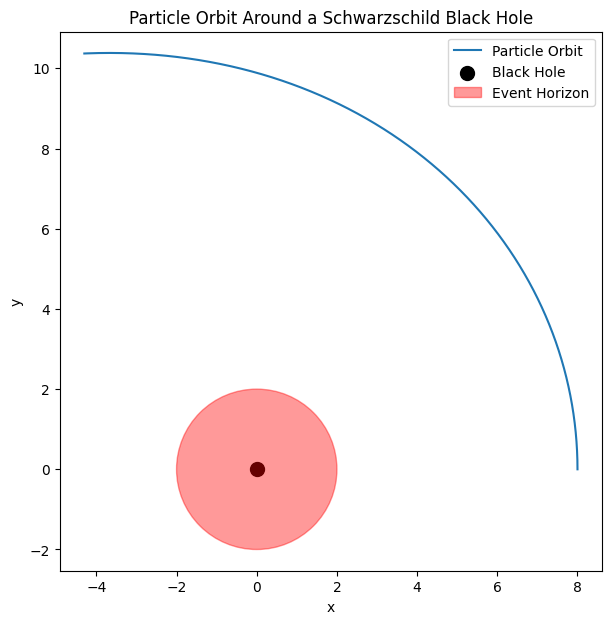

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

# Plot particle trajectory
plt.plot(x, y, label="Particle Orbit")

# Black hole at the center
plt.scatter(0, 0, color='black', s=100, label='Black Hole')

# Event horizon (r = 2M)
circle = plt.Circle((0, 0), 2*M, color='red', alpha=0.4, label='Event Horizon')
plt.gca().add_patch(circle)

plt.axis('equal')
plt.xlabel("x")
plt.ylabel("y")
plt.title("Particle Orbit Around a Schwarzschild Black Hole")
plt.legend()

plt.show()

The particle's trajectory is plotted in Cartesian coordinates (x,y) to visualize its motion around the Schwarzschild black hole. The black dot at the center represents the black hole, while the red circle indicates the event horizon (r=2M). The resulting plot illustrates the path followed by the particle under the influence of spacetime curvature, allowing stable, capture, or escape trajectories to be observed depending on the chosen initial conditions.